In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

In [ ]:
df = pd.read_excel("002 flight-price.xlsx")
df.head(10)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
5,SpiceJet,24/06/2019,Kolkata,Banglore,CCU → BLR,09:00,11:25,2h 25m,non-stop,No info,3873
6,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,18:55,10:25 13 Mar,15h 30m,1 stop,In-flight meal not included,11087
7,Jet Airways,01/03/2019,Banglore,New Delhi,BLR → BOM → DEL,08:00,05:05 02 Mar,21h 5m,1 stop,No info,22270
8,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,08:55,10:25 13 Mar,25h 30m,1 stop,In-flight meal not included,11087
9,Multiple carriers,27/05/2019,Delhi,Cochin,DEL → BOM → COK,11:25,19:15,7h 50m,1 stop,No info,8625


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [ ]:
## For conversion of Date of Journey Column into Integer
## First spliting the Date of journey into Day, Month and Year Column

df['Day'] = df['Date_of_Journey'].str.split('/').str[0]
df['Month'] = df['Date_of_Journey'].str.split('/').str[1]
df['Year'] = df['Date_of_Journey'].str.split('/').str[2]

In [ ]:
df.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,03,2019
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,05,2019


In [ ]:
## Converting the columns into integer format using astype funtion

df['Day'] = df['Day'].astype(int)
df['Month'] = df['Month'].astype(int)
df['Year'] = df['Year'].astype(int)

In [ ]:
## As Date of Journey is no longer required we will drop the column

df.drop('Date_of_Journey', axis=1, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Source           10683 non-null  object
 2   Destination      10683 non-null  object
 3   Route            10682 non-null  object
 4   Dep_Time         10683 non-null  object
 5   Arrival_Time     10683 non-null  object
 6   Duration         10683 non-null  object
 7   Total_Stops      10682 non-null  object
 8   Additional_Info  10683 non-null  object
 9   Price            10683 non-null  int64 
 10  Day              10683 non-null  int64 
 11  Month            10683 non-null  int64 
 12  Year             10683 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 1.1+ MB


In [ ]:
df.head(2)

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019


In [ ]:
df['Arrival_Time'] = df['Arrival_Time'].str.split(' ').str[0]

In [ ]:
df['Arrival_Hour'] = df['Arrival_Time'].str.split(':').str[0]
df['Arrival_Minute'] = df['Arrival_Time'].str.split(':').str[1]

In [ ]:
df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Arrival_Hour,Arrival_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10,2h 50m,non-stop,No info,3897,24,3,2019,01,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25,19h,2 stops,No info,13882,9,6,2019,04,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019,21,35


In [ ]:
df.drop('Arrival_Time', axis=1, inplace=True)

In [ ]:
df['Arrival_Hour'] = df['Arrival_Hour'].astype(int)
df['Arrival_Minute'] = df['Arrival_Minute'].astype(int)

In [ ]:
df['Dep_Hour'] = df['Dep_Time'].str.split(':').str[0]
df['Dep_Minute'] = df['Dep_Time'].str.split(':').str[1]

In [ ]:
df['Dep_Hour'] = df['Dep_Hour'].astype(int)
df['Dep_Minute'] = df['Dep_Minute'].astype(int)

In [ ]:
df.drop('Dep_Time', axis=1, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Source           10683 non-null  object
 2   Destination      10683 non-null  object
 3   Route            10682 non-null  object
 4   Duration         10683 non-null  object
 5   Total_Stops      10682 non-null  object
 6   Additional_Info  10683 non-null  object
 7   Price            10683 non-null  int64 
 8   Day              10683 non-null  int64 
 9   Month            10683 non-null  int64 
 10  Year             10683 non-null  int64 
 11  Arrival_Hour     10683 non-null  int64 
 12  Arrival_Minute   10683 non-null  int64 
 13  Dep_Hour         10683 non-null  int64 
 14  Dep_Minute       10683 non-null  int64 
dtypes: int64(8), object(7)
memory usage: 1.2+ MB


In [ ]:
df['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops'],
      dtype=object)

In [ ]:
df.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,13,15,5,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,2019,4,25,9,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,2019,23,30,18,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,2019,21,35,16,50


In [ ]:
df['Total_Stops']=df['Total_Stops'].map({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4})

In [ ]:
df.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,0.0,No info,3897,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2.0,No info,7662,1,5,2019,13,15,5,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2.0,No info,13882,9,6,2019,4,25,9,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1.0,No info,6218,12,5,2019,23,30,18,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1.0,No info,13302,1,3,2019,21,35,16,50


In [ ]:
df.drop('Route', axis=1, inplace=True)

In [ ]:
df.head(2)

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute
0,IndiGo,Banglore,New Delhi,2h 50m,0.0,No info,3897,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,7h 25m,2.0,No info,7662,1,5,2019,13,15,5,50


In [ ]:
df['Dur_hour'] = df['Duration'].str.split(' ').str[0].str.split('h').str[0]

In [ ]:
df['Dur_min'] = df['Duration'].str.split(' ').str[1].str.split('m').str[0]

In [ ]:
df.head(2)

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute,Dur_hour,Dur_min
0,IndiGo,Banglore,New Delhi,2h 50m,0.0,No info,3897,24,3,2019,1,10,22,20,2,50
1,Air India,Kolkata,Banglore,7h 25m,2.0,No info,7662,1,5,2019,13,15,5,50,7,25


In [ ]:
df.drop('Duration', axis=1, inplace=True)

In [ ]:
df['Dur_min']

,Dur_min
0,50
1,25
2,NaN
3,25
4,45
...,...
10678,30
10679,35
10680,NaN
10681,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          10683 non-null  object 
 1   Source           10683 non-null  object 
 2   Destination      10683 non-null  object 
 3   Total_Stops      10682 non-null  float64
 4   Additional_Info  10683 non-null  object 
 5   Price            10683 non-null  int64  
 6   Day              10683 non-null  int64  
 7   Month            10683 non-null  int64  
 8   Year             10683 non-null  int64  
 9   Arrival_Hour     10683 non-null  int64  
 10  Arrival_Minute   10683 non-null  int64  
 11  Dep_Hour         10683 non-null  int64  
 12  Dep_Minute       10683 non-null  int64  
 13  Dur_hour         10683 non-null  object 
 14  Dur_min          9651 non-null   object 
dtypes: float64(1), int64(8), object(6)
memory usage: 1.2+ MB


In [ ]:
df['Dur_min'].unique()

array(['50', '25', nan, '45', '30', '5', '15', '35', '10', '20', '55',
       '40'], dtype=object)

In [ ]:
df['Dur_min'].mode()

,Dur_min
0,30


In [ ]:
df1 = df

In [ ]:
df1['Dur_min'] = df1['Dur_min'].fillna(df1['Dur_min'].mode()[0])

In [ ]:
df1['Dur_hour'] = pd.to_numeric(df1['Dur_hour'], errors='coerce')
df1['Dur_min'] = pd.to_numeric(df1['Dur_min'], errors='coerce')

# Fill any new NaNs that might have been created during conversion to numeric
# Assuming 0 hours for NaN
df1['Dur_hour'] = df1['Dur_hour'].fillna(0).astype(int)
df1['Dur_min'] = df1['Dur_min'].fillna(df1['Dur_min'].mode()[0]).astype(int)

df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          10683 non-null  object 
 1   Source           10683 non-null  object 
 2   Destination      10683 non-null  object 
 3   Total_Stops      10682 non-null  float64
 4   Additional_Info  10683 non-null  object 
 5   Price            10683 non-null  int64  
 6   Day              10683 non-null  int64  
 7   Month            10683 non-null  int64  
 8   Year             10683 non-null  int64  
 9   Arrival_Hour     10683 non-null  int64  
 10  Arrival_Minute   10683 non-null  int64  
 11  Dep_Hour         10683 non-null  int64  
 12  Dep_Minute       10683 non-null  int64  
 13  Dur_hour         10683 non-null  int64  
 14  Dur_min          10683 non-null  int64  
dtypes: float64(1), int64(10), object(4)
memory usage: 1.2+ MB


In [ ]:
display(df1['Dur_min'].unique())

array([50, 25, 30, 45,  5, 15, 35, 10, 20, 55, 40])

In [ ]:
df['Dur_min']

,Dur_min
0,50
1,25
2,30
3,25
4,45
...,...
10678,30
10679,35
10680,30
10681,40


In [ ]:
display(df1.head())
display(df1['Dur_min'].value_counts(dropna=False))

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Day,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute,Dur_hour,Dur_min
0,IndiGo,Banglore,New Delhi,0.0,No info,3897,24,3,2019,1,10,22,20,2,50
1,Air India,Kolkata,Banglore,2.0,No info,7662,1,5,2019,13,15,5,50,7,25
2,Jet Airways,Delhi,Cochin,2.0,No info,13882,9,6,2019,4,25,9,25,19,30
3,IndiGo,Kolkata,Banglore,1.0,No info,6218,12,5,2019,23,30,18,5,5,25
4,IndiGo,Banglore,New Delhi,1.0,No info,13302,1,3,2019,21,35,16,50,4,45


,count
Dur_min,
30,2478
20,997
50,972
35,939
55,910
15,903
45,896
25,803
40,637


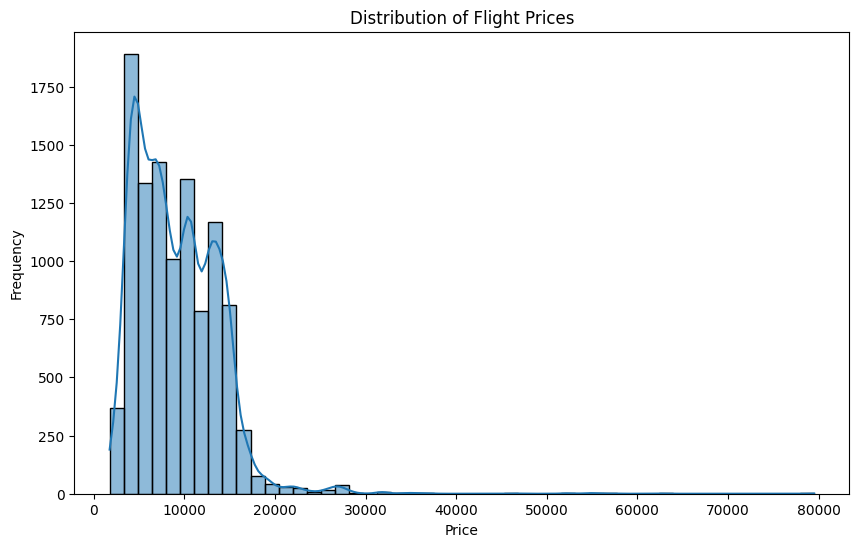

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribution of Flight Prices
plt.figure(figsize=(10, 6))
sns.histplot(df1['Price'], bins=50, kde=True)
plt.title('Distribution of Flight Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

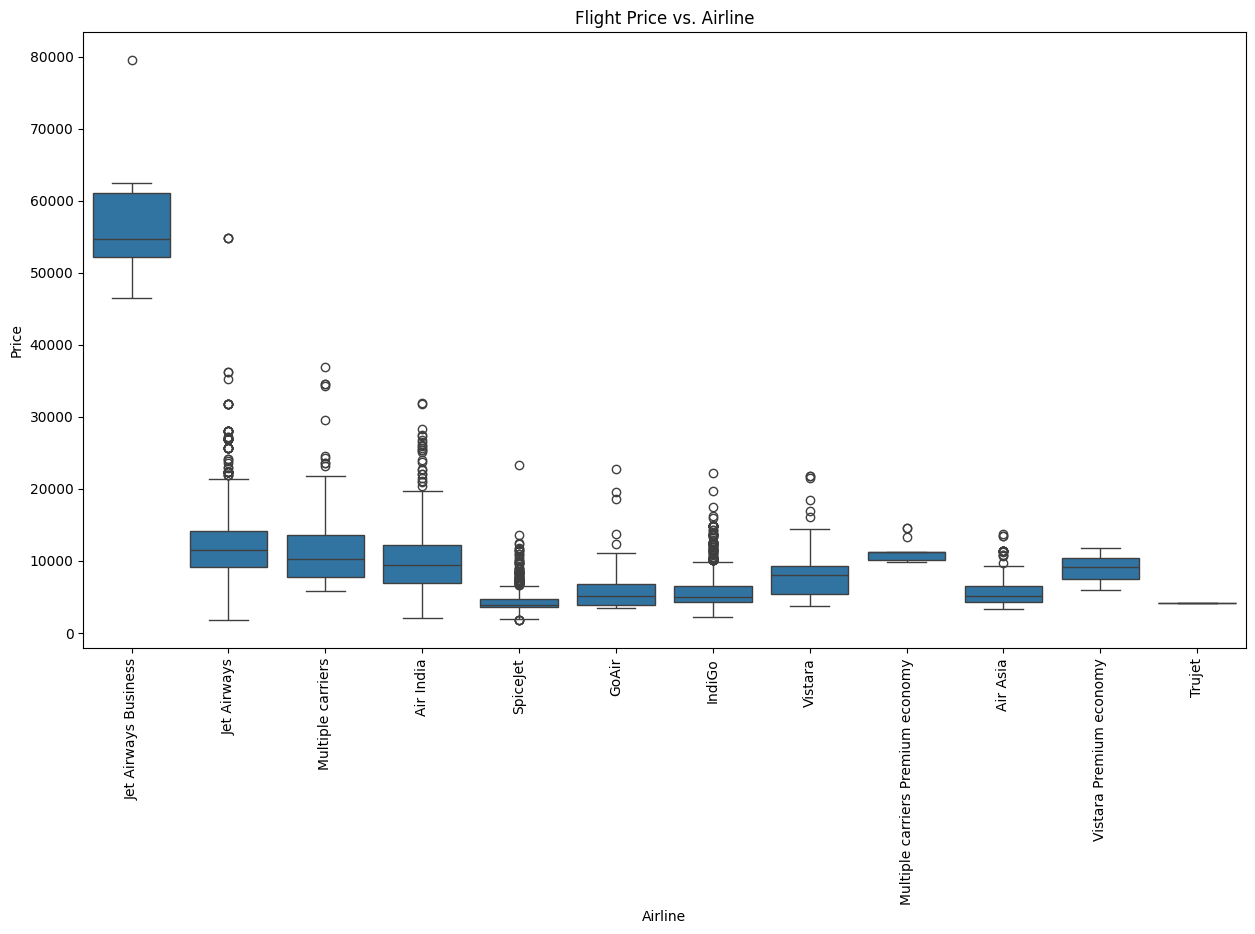

In [ ]:
# 2. Price vs. Airline
plt.figure(figsize=(15, 8))
sns.boxplot(x='Airline', y='Price', data=df1.sort_values('Price', ascending=False))
plt.title('Flight Price vs. Airline')
plt.xlabel('Airline')
plt.ylabel('Price')
plt.xticks(rotation=90)
plt.show()

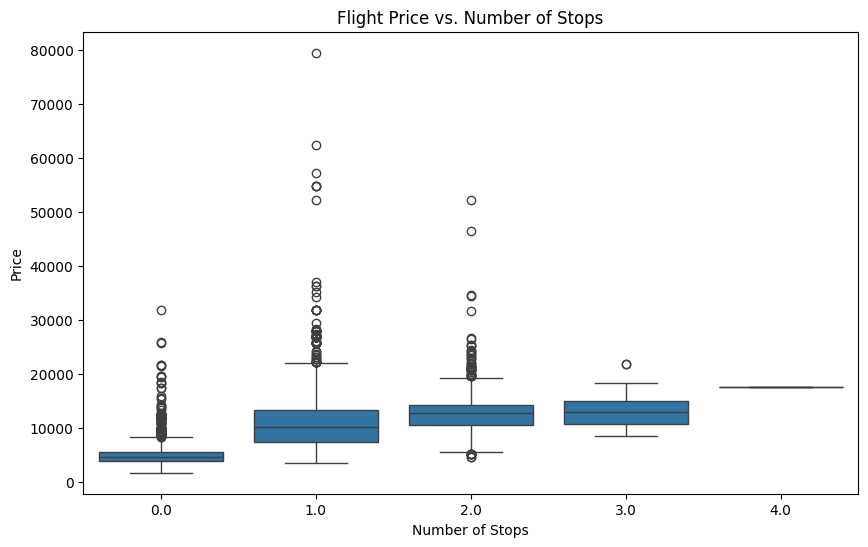

In [ ]:
# 3. Price vs. Total Stops
plt.figure(figsize=(10, 6))
sns.boxplot(x='Total_Stops', y='Price', data=df1.sort_values('Price', ascending=False))
plt.title('Flight Price vs. Number of Stops')
plt.xlabel('Number of Stops')
plt.ylabel('Price')
plt.show()

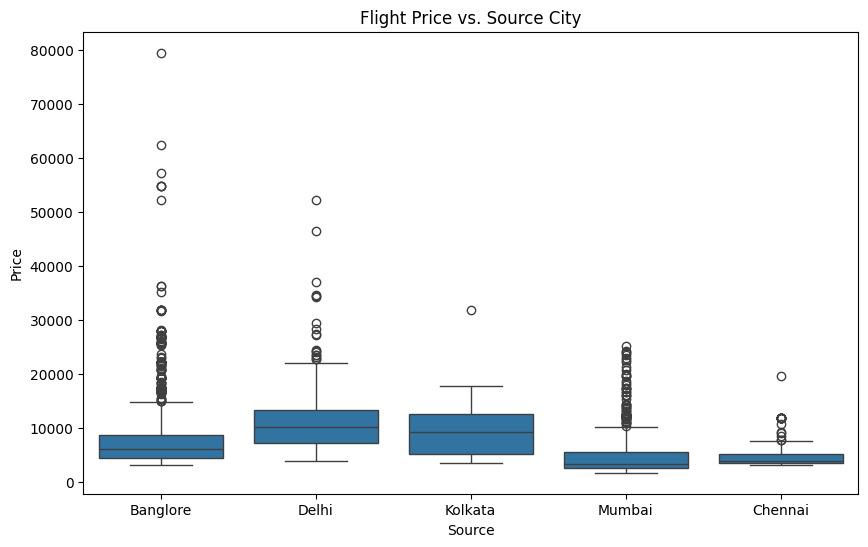

In [ ]:
# 4. Price vs. Source
plt.figure(figsize=(10, 6))
sns.boxplot(x='Source', y='Price', data=df1.sort_values('Price', ascending=False))
plt.title('Flight Price vs. Source City')
plt.xlabel('Source')
plt.ylabel('Price')
plt.show()

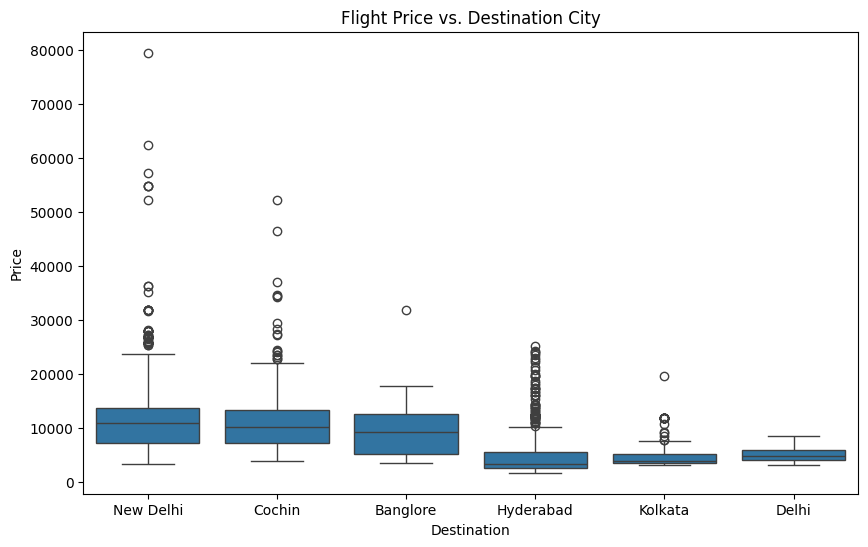

In [ ]:
# 5. Price vs. Destination
plt.figure(figsize=(10, 6))
sns.boxplot(x='Destination', y='Price', data=df1.sort_values('Price', ascending=False))
plt.title('Flight Price vs. Destination City')
plt.xlabel('Destination')
plt.ylabel('Price')
plt.show()

In [ ]:
df1['Additional_Info'].unique()

array(['No info', 'In-flight meal not included',
       'No check-in baggage included', '1 Short layover', 'No Info',
       '1 Long layover', 'Change airports', 'Business class',
       'Red-eye flight', '2 Long layover'], dtype=object)

In [ ]:
df1['Total_Stops'].isnull().sum()

np.int64(1)

In [ ]:
## Standard Scaling
from sklearn.preprocessing import StandardScaler

numerical_features = ['Day', 'Month', 'Year', 'Arrival_Hour', 'Arrival_Minute', 'Dep_Hour', 'Dep_Minute', 'Dur_hour', 'Dur_min', 'Total_Stops']

scaler = StandardScaler()

df1[numerical_features] = scaler.fit_transform(df1[numerical_features])

df1.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Day,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute,Dur_hour,Dur_min
0,IndiGo,Banglore,New Delhi,-1.229259,No info,3897,1.237383,-1.467490,0.0,-1.800427,-0.890057,1.654259,-0.235050,-0.976072,1.322625
1,Air India,Kolkata,Banglore,1.761845,No info,7662,-1.475239,0.250276,0.0,-0.050851,-0.587124,-1.303095,1.363492,-0.382640,-0.438556
2,Jet Airways,Delhi,Cochin,1.761845,No info,13882,-0.531719,1.109160,0.0,-1.363033,0.018744,-0.607247,0.031373,1.041598,-0.086320
3,IndiGo,Kolkata,Banglore,0.266293,No info,6218,-0.177898,0.250276,0.0,1.407129,0.321677,0.958411,-1.034321,-0.620013,-0.438556
4,IndiGo,Banglore,New Delhi,0.266293,No info,13302,-1.475239,-1.467490,0.0,1.115533,0.624611,0.610487,1.363492,-0.738699,0.970389


In [ ]:
for col in numerical_features:
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers
    df1[col] = np.where(df1[col] < lower_bound, lower_bound, df1[col])
    df1[col] = np.where(df1[col] > upper_bound, upper_bound, df1[col])

print("Outliers handled in scaled numerical features.")
df1.head()

Outliers handled in scaled numerical features.


,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Day,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute,Dur_hour,Dur_min
0,IndiGo,Banglore,New Delhi,-1.229259,No info,3897,1.237383,-1.467490,0.0,-1.800427,-0.890057,1.654259,-0.235050,-0.976072,1.322625
1,Air India,Kolkata,Banglore,1.761845,No info,7662,-1.475239,0.250276,0.0,-0.050851,-0.587124,-1.303095,1.363492,-0.382640,-0.438556
2,Jet Airways,Delhi,Cochin,1.761845,No info,13882,-0.531719,1.109160,0.0,-1.363033,0.018744,-0.607247,0.031373,1.041598,-0.086320
3,IndiGo,Kolkata,Banglore,0.266293,No info,6218,-0.177898,0.250276,0.0,1.407129,0.321677,0.958411,-1.034321,-0.620013,-0.438556
4,IndiGo,Banglore,New Delhi,0.266293,No info,13302,-1.475239,-1.467490,0.0,1.115533,0.624611,0.610487,1.363492,-0.738699,0.970389


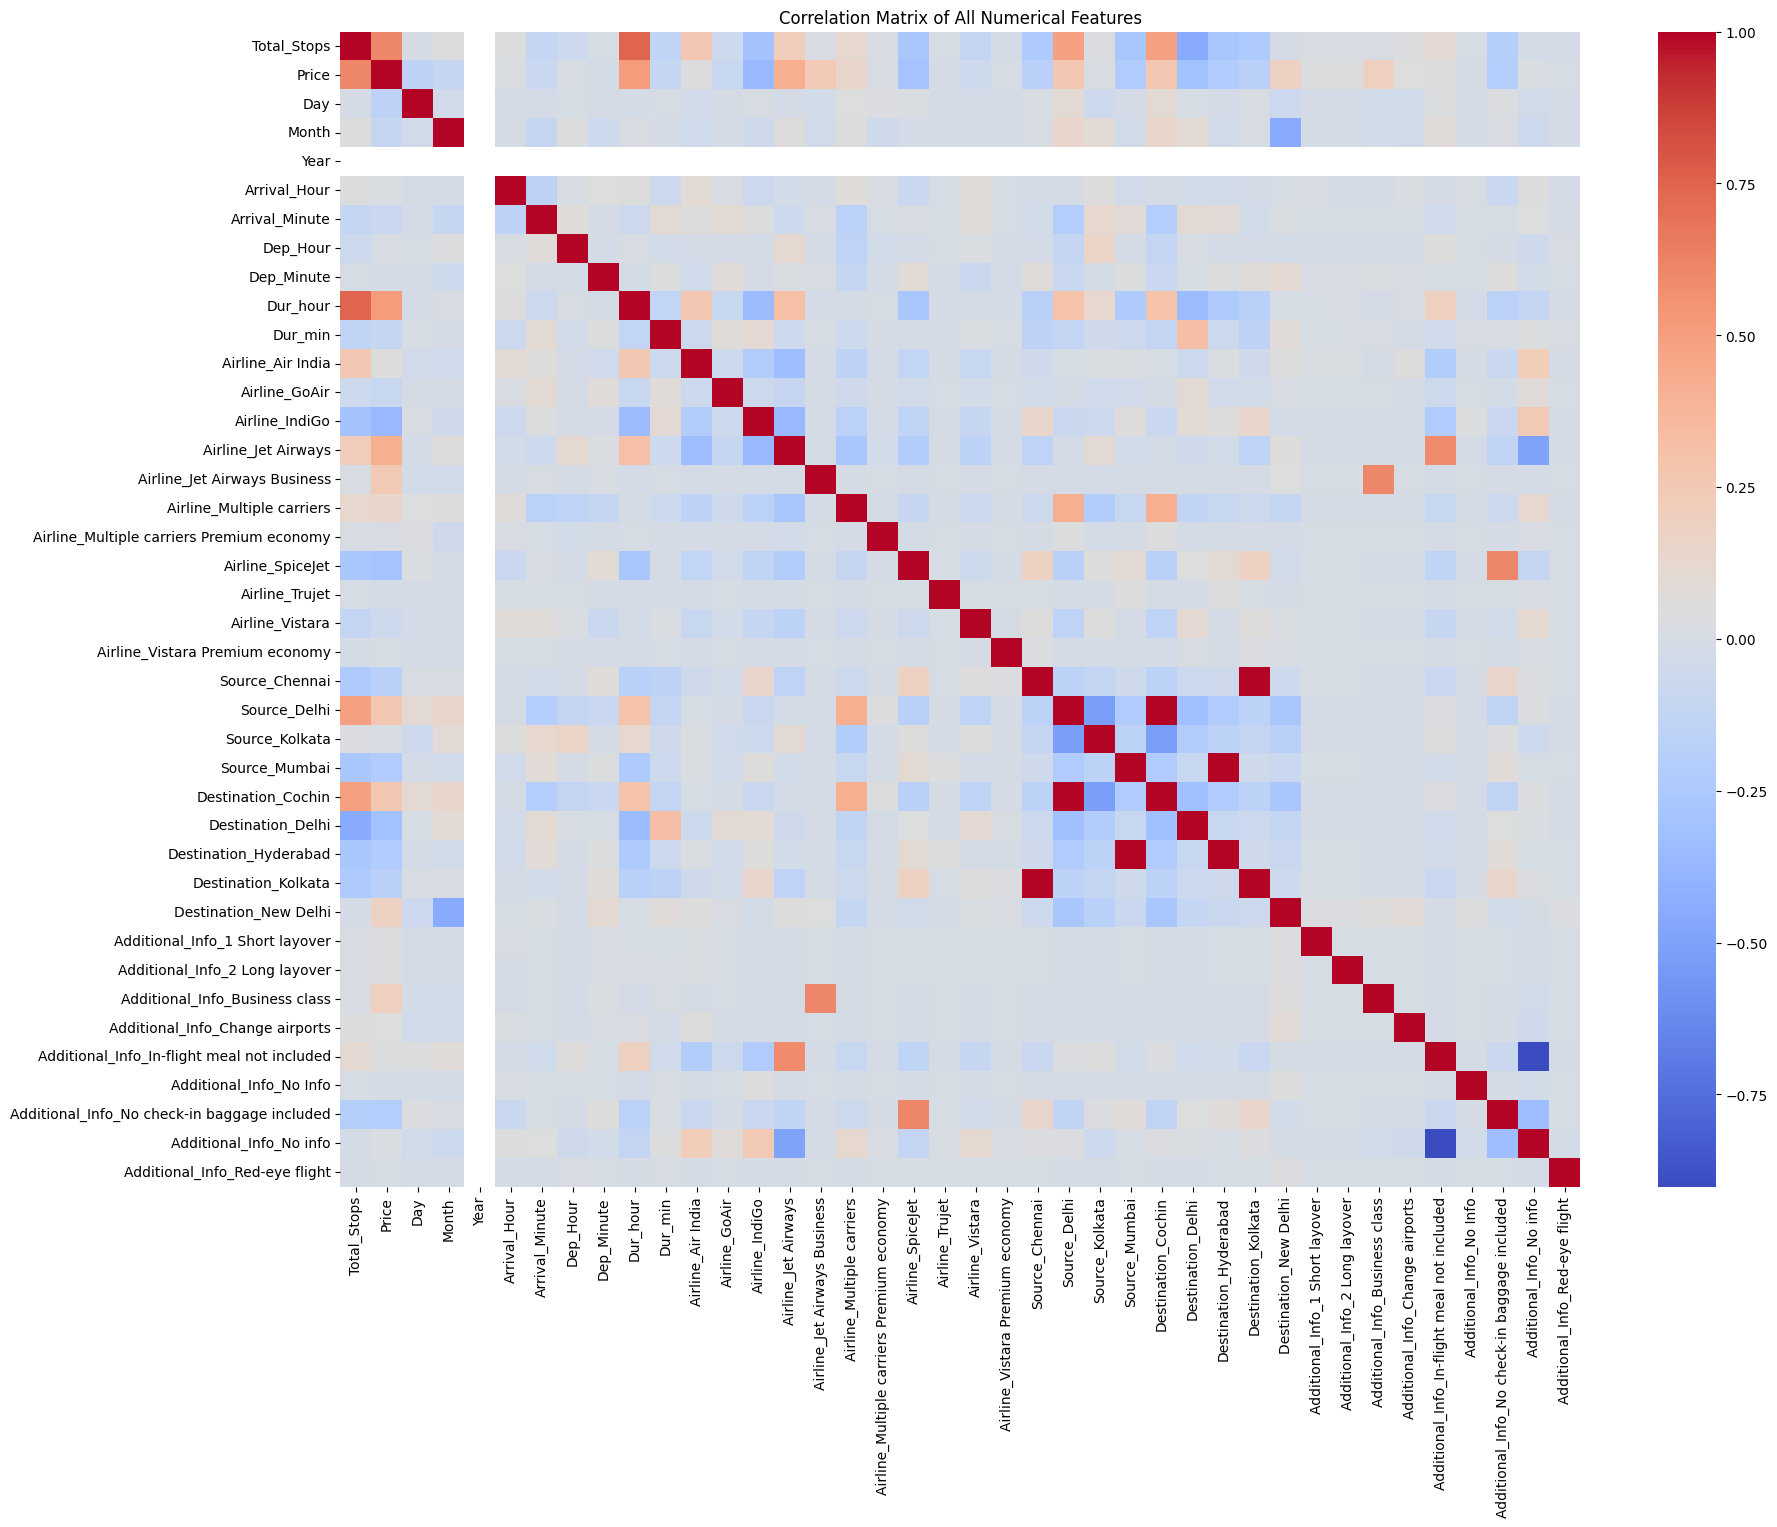

In [ ]:
import numpy as np

# Convert boolean columns to int (0 or 1) for correlation calculation
for col in df1.columns:
    if df1[col].dtype == 'bool':
        df1[col] = df1[col].astype(int)

# Calculate the correlation matrix
correlation_matrix = df1.corr()

# Plot the heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of All Numerical Features')
plt.show()

In [ ]:
from scipy.stats import norm

# 1. Extract the 'Price' column for 'IndiGo' flights
indigo_prices = df1[df1['Airline_IndiGo'] == 1]['Price']

# 2. Calculate the overall mean price of all flights
overall_mean_price = df1['Price'].mean()

# 3. Calculate the mean of indigo_prices
indigo_mean_price = indigo_prices.mean()

# 4. Calculate the standard deviation of indigo_prices
indigo_std_dev = indigo_prices.std()

# 5. Get the sample size of indigo_prices
indigo_n = len(indigo_prices)

print(f"Overall Mean Price: {overall_mean_price:.2f}")
print(f"IndiGo Mean Price: {indigo_mean_price:.2f}")
print(f"IndiGo Standard Deviation: {indigo_std_dev:.2f}")
print(f"IndiGo Sample Size: {indigo_n}")

Overall Mean Price: 9087.06
IndiGo Mean Price: 5673.68
IndiGo Standard Deviation: 2264.14
IndiGo Sample Size: 2053


In [ ]:
import numpy as np
from scipy.stats import norm

# Define null and alternative hypotheses
print("\n--- Z-test for IndiGo Flight Prices vs. Overall Mean Price ---")
print("Null Hypothesis (H0): The mean price of IndiGo flights is equal to the overall mean flight price.")
print("Alternative Hypothesis (H1): The mean price of IndiGo flights is significantly different from the overall mean flight price.")

# Calculate the Z-statistic
z_statistic = (indigo_mean_price - overall_mean_price) / (indigo_std_dev / np.sqrt(indigo_n))

# Calculate the p-value for a two-tailed test
p_value = 2 * norm.cdf(-abs(z_statistic))

print(f"Z-statistic: {z_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

alfa = 0.05
if p_value < alfa:
    print(f"Conclusion: Since the p-value ({p_value:.4f}) is less than the significance level ({alfa}), we reject the null hypothesis. There is a statistically significant difference in the mean price of IndiGo flights compared to the overall mean flight price.")
else:
    print(f"Conclusion: Since the p-value ({p_value:.4f}) is greater than the significance level ({alfa}), we fail to reject the null hypothesis. There is no statistically significant difference in the mean price of IndiGo flights compared to the overall mean flight price.")


--- Z-test for IndiGo Flight Prices vs. Overall Mean Price ---
Null Hypothesis (H0): The mean price of IndiGo flights is equal to the overall mean flight price.
Alternative Hypothesis (H1): The mean price of IndiGo flights is significantly different from the overall mean flight price.
Z-statistic: -68.3086
P-value: 0.0000
Conclusion: Since the p-value (0.0000) is less than the significance level (0.05), we reject the null hypothesis. There is a statistically significant difference in the mean price of IndiGo flights compared to the overall mean flight price.


In [ ]:
from scipy import stats

# Define null and alternative hypotheses
print("\n--- Two-Sample Independent T-test for IndiGo vs. SpiceJet Prices ---")
print("Null Hypothesis (H0): There is no significant difference in the mean prices between IndiGo and SpiceJet.")
print("Alternative Hypothesis (H1): There is a significant difference in the mean prices between IndiGo and SpiceJet.")

# Perform Two-Sample Independent T-test
t_statistic, p_value = stats.ttest_ind(indigo_prices, spicejet_prices)

print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

alfa = 0.05
if p_value < alfa:
    print(f"Conclusion: Since the p-value ({p_value:.4f}) is less than the significance level ({alfa}), we reject the null hypothesis. There is a statistically significant difference in mean flight prices between IndiGo and SpiceJet.")
else:
    print(f"Conclusion: Since the p-value ({p_value:.4f}) is greater than the significance level ({alfa}), we fail to reject the null hypothesis. There is no statistically significant difference in mean flight prices between IndiGo and SpiceJet.")


--- Two-Sample Independent T-test for IndiGo vs. SpiceJet Prices ---
Null Hypothesis (H0): There is no significant difference in the mean prices between IndiGo and SpiceJet.
Alternative Hypothesis (H1): There is a significant difference in the mean prices between IndiGo and SpiceJet.
T-statistic: 14.9919
P-value: 0.0000
Conclusion: Since the p-value (0.0000) is less than the significance level (0.05), we reject the null hypothesis. There is a statistically significant difference in mean flight prices between IndiGo and SpiceJet.


In [ ]:
from scipy.stats import chi2_contingency

# Load a fresh copy of the dataset to ensure original categorical columns are available
# This handles the case where 'Airline' and 'Source' might have been dropped from df1 during one-hot encoding
original_df_for_chi2 = pd.read_excel("002 flight-price.xlsx")

# Create a contingency table between 'Airline' and 'Source' from the fresh dataframe
contingency_table = pd.crosstab(original_df_for_chi2['Airline'], original_df_for_chi2['Source'])

print("Contingency Table (Airline vs. Source):\n")
print(contingency_table.head())

# Perform the Chi-Square test of independence
chi2_statistic, p_value, dof, expected_frequencies = chi2_contingency(contingency_table)

print("\n--- Chi-Square Test of Independence for Airline and Source ---")
print(f"Chi-Square Statistic: {chi2_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")

alfa = 0.05
if p_value < alfa:
    print(f"Conclusion: Since the p-value ({p_value:.4f}) is less than the significance level ({alfa}), we reject the null hypothesis.")
    print("There is a statistically significant association between the 'Airline' and 'Source' features.")
else:
    print(f"Conclusion: Since the p-value ({p_value:.4f}) is greater than the significance level ({alfa}), we fail to reject the null hypothesis.")
    print("There is no statistically significant association between the 'Airline' and 'Source' features.")

Contingency Table (Airline vs. Source):

Source       Banglore  Chennai  Delhi  Kolkata  Mumbai
Airline                                               
Air Asia           89        0     80      150       0
Air India         332       25    747      512     136
GoAir              93        0     76       25       0
IndiGo            523      184    705      445     196
Jet Airways       788        0   1586     1256     219

--- Chi-Square Test of Independence for Airline and Source ---
Chi-Square Statistic: 3297.6706
P-value: 0.0000
Degrees of Freedom: 44
Conclusion: Since the p-value (0.0000) is less than the significance level (0.05), we reject the null hypothesis.
There is a statistically significant association between the 'Airline' and 'Source' features.



--- Descriptive Statistics for Price ---
count    10683.000000
mean      9087.064121
std       4611.359167
min       1759.000000
25%       5277.000000
50%       8372.000000
75%      12373.000000
max      79512.000000
Name: Price, dtype: float64


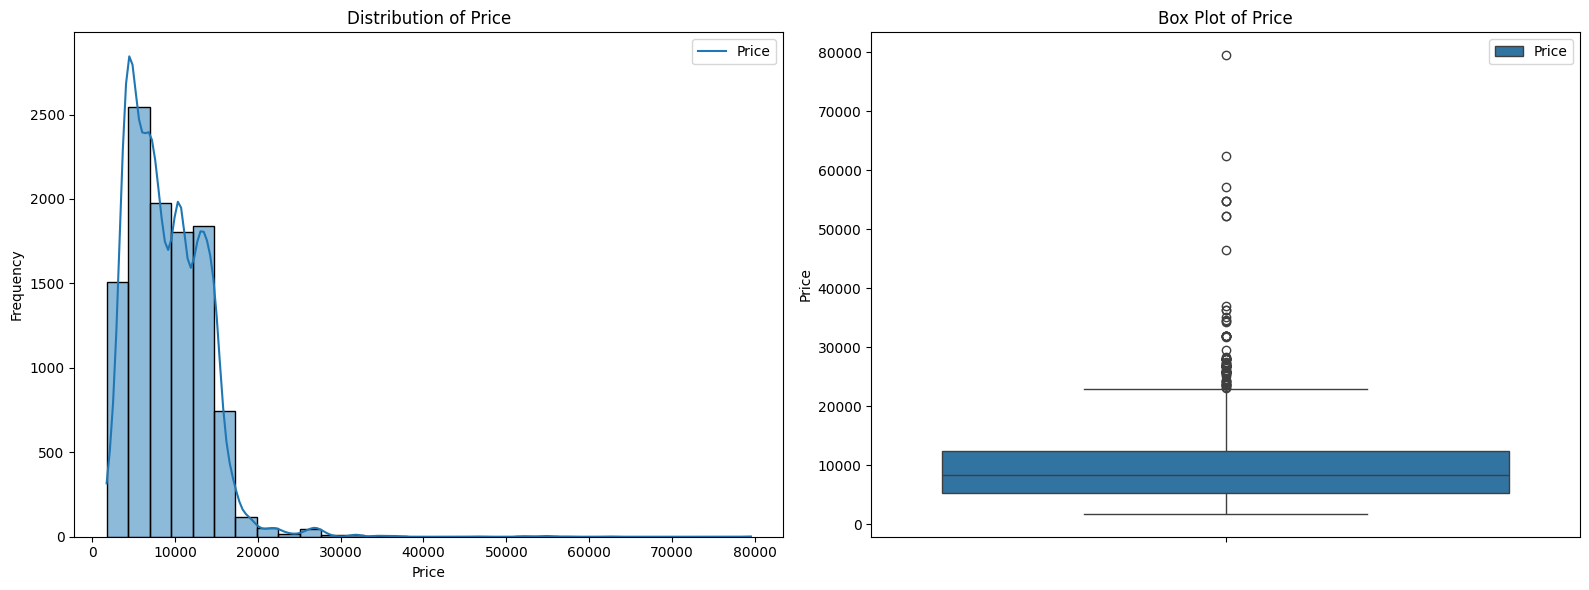


--- Descriptive Statistics for Dur_hour ---
count    1.068300e+04
mean     1.662788e-18
std      1.000047e+00
min     -1.213445e+00
25%     -9.760723e-01
50%     -2.639533e-01
75%      5.668522e-01
max      2.881239e+00
Name: Dur_hour, dtype: float64


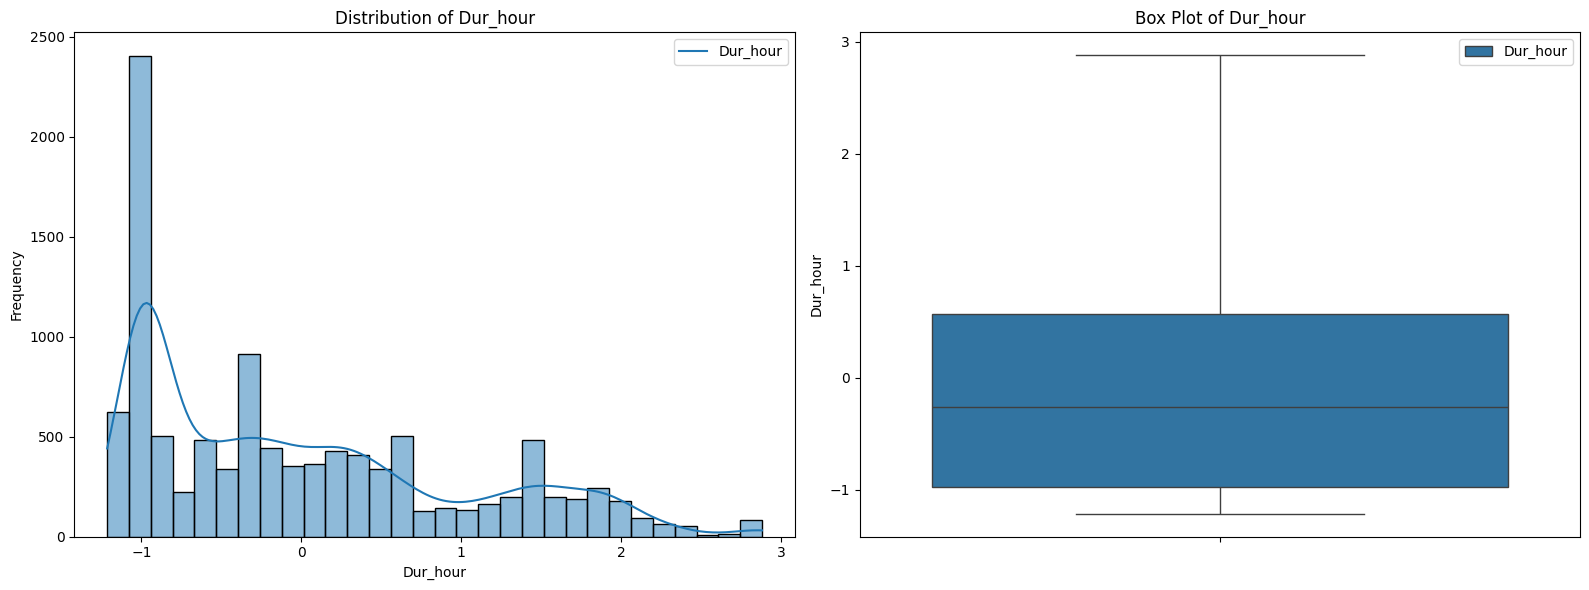


--- Descriptive Statistics for Dur_min ---
count    1.068300e+04
mean     3.990692e-17
std      1.000047e+00
min     -1.847500e+00
25%     -7.907920e-01
50%     -8.631977e-02
75%      9.703886e-01
max      1.674861e+00
Name: Dur_min, dtype: float64


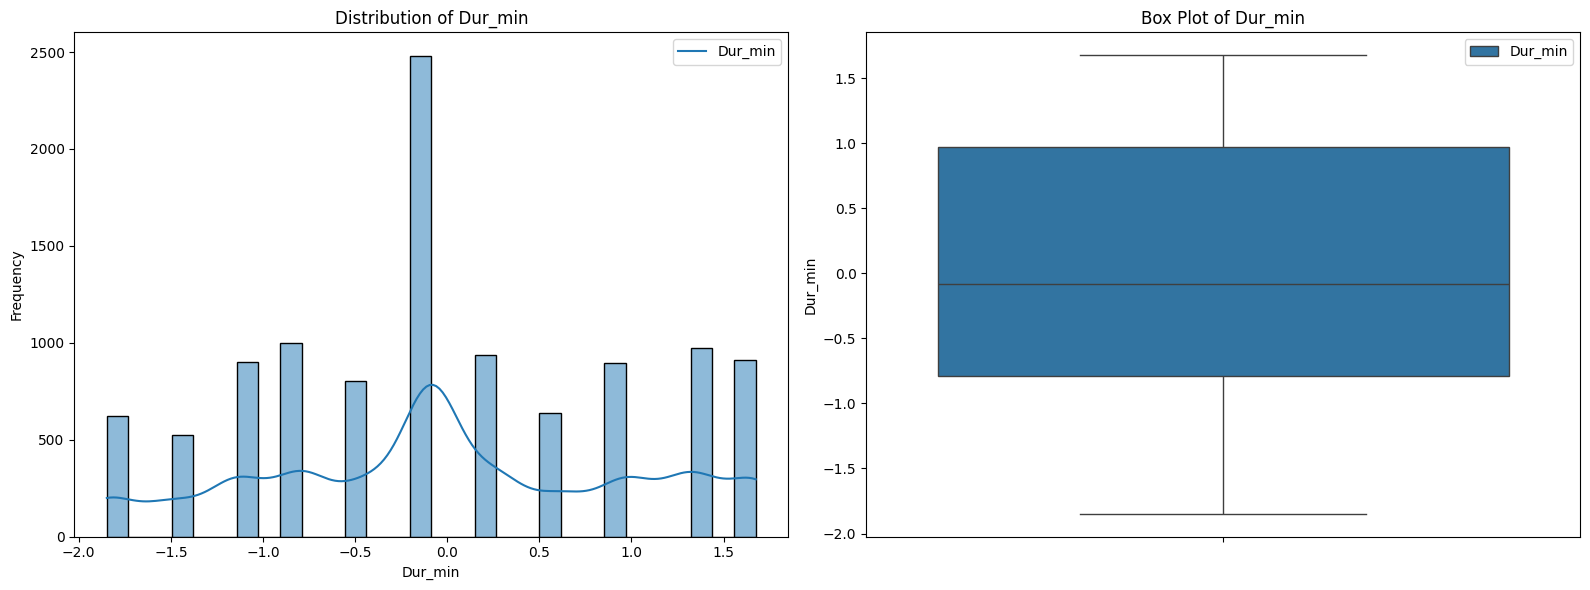


--- Descriptive Statistics for Total_Stops ---
count    10682.000000
mean         0.000000
std          1.000047
min         -1.229259
25%         -1.229259
50%          0.266293
75%          0.266293
max          2.509621
Name: Total_Stops, dtype: float64


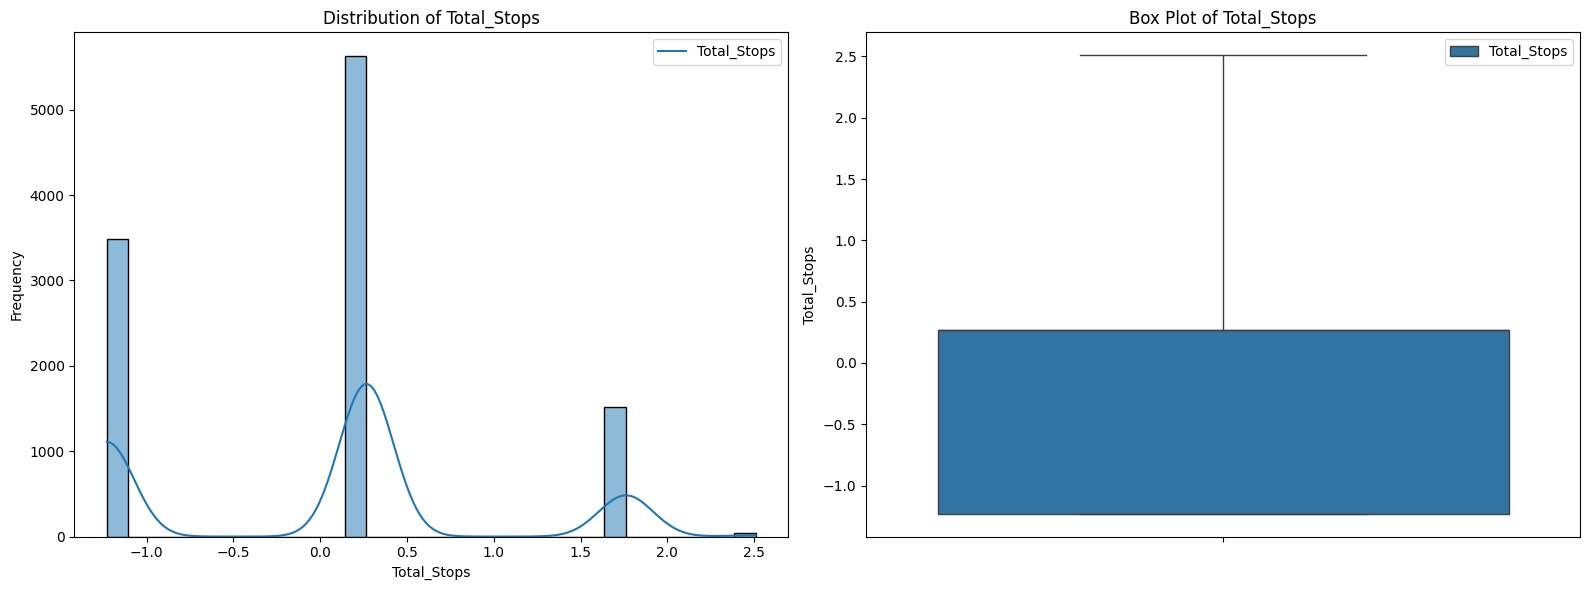

In [ ]:
numerical_features_to_analyze = ['Price', 'Dur_hour', 'Dur_min', 'Total_Stops']

for feature in numerical_features_to_analyze:
    print(f"\n--- Descriptive Statistics for {feature} ---")
    print(df1[feature].describe())

    plt.figure(figsize=(16, 6))

    # Histogram with KDE
    plt.subplot(1, 2, 1)
    sns.histplot(df1[feature], bins=30, kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.legend(labels=[feature])

    # Box Plot
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df1[feature])
    plt.title(f'Box Plot of {feature}')
    plt.ylabel(feature)
    plt.legend(labels=[feature])

    plt.tight_layout()
    plt.show()

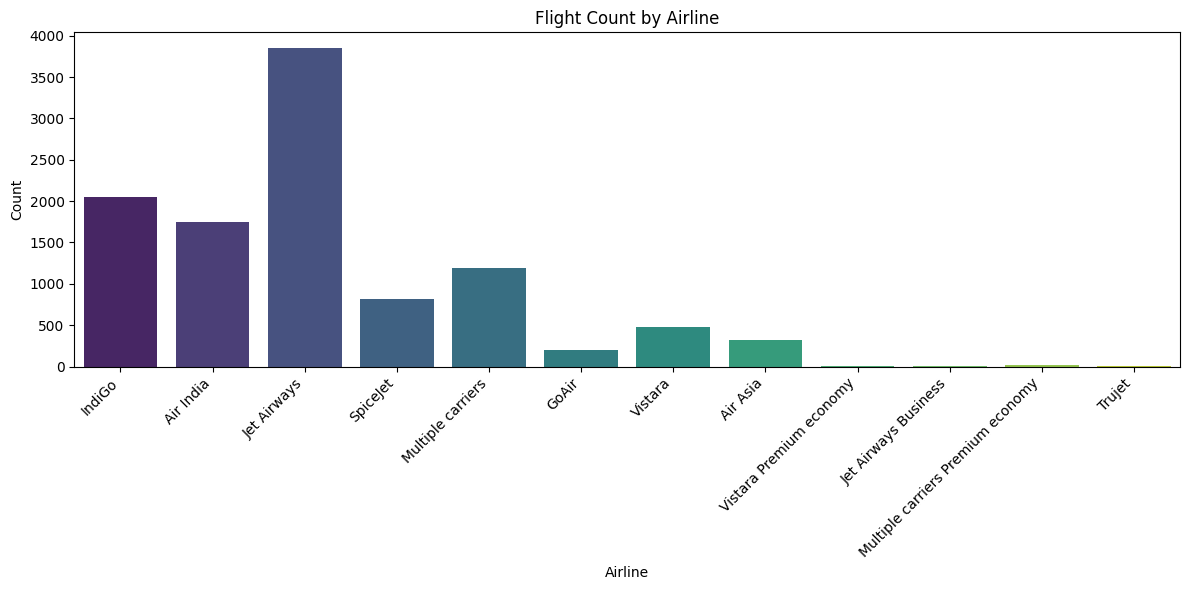

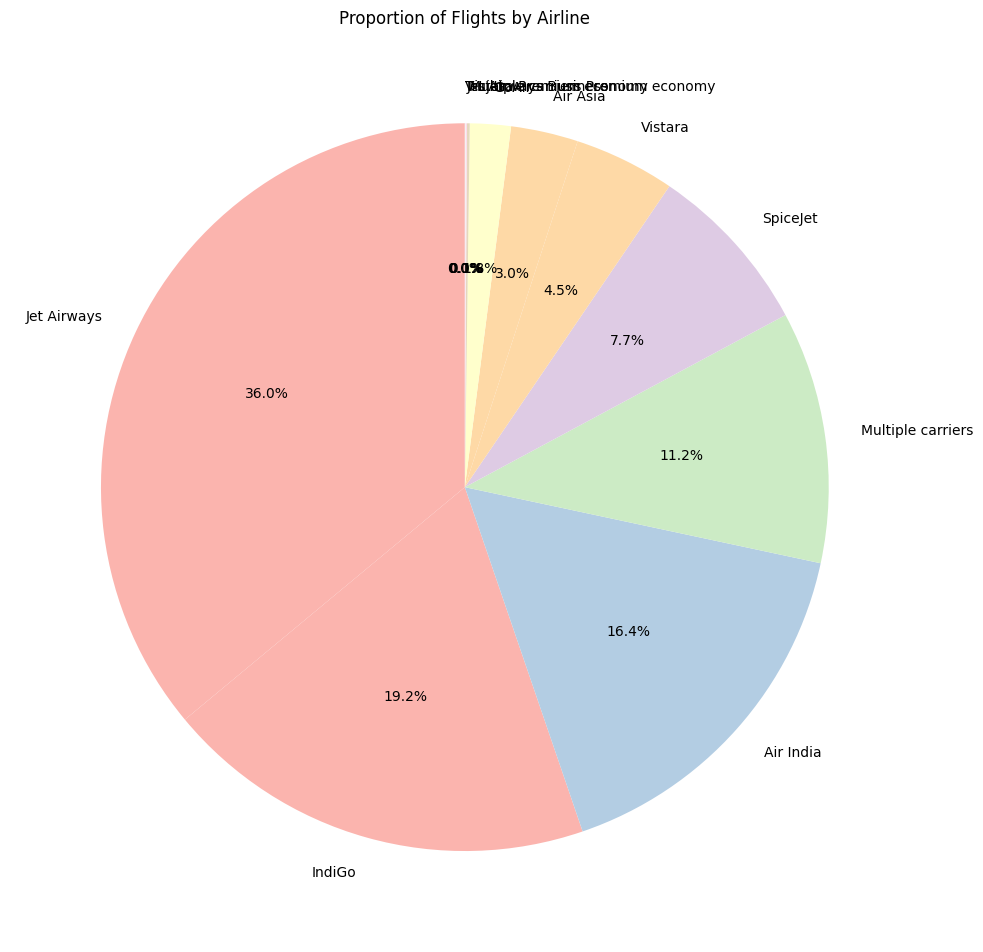

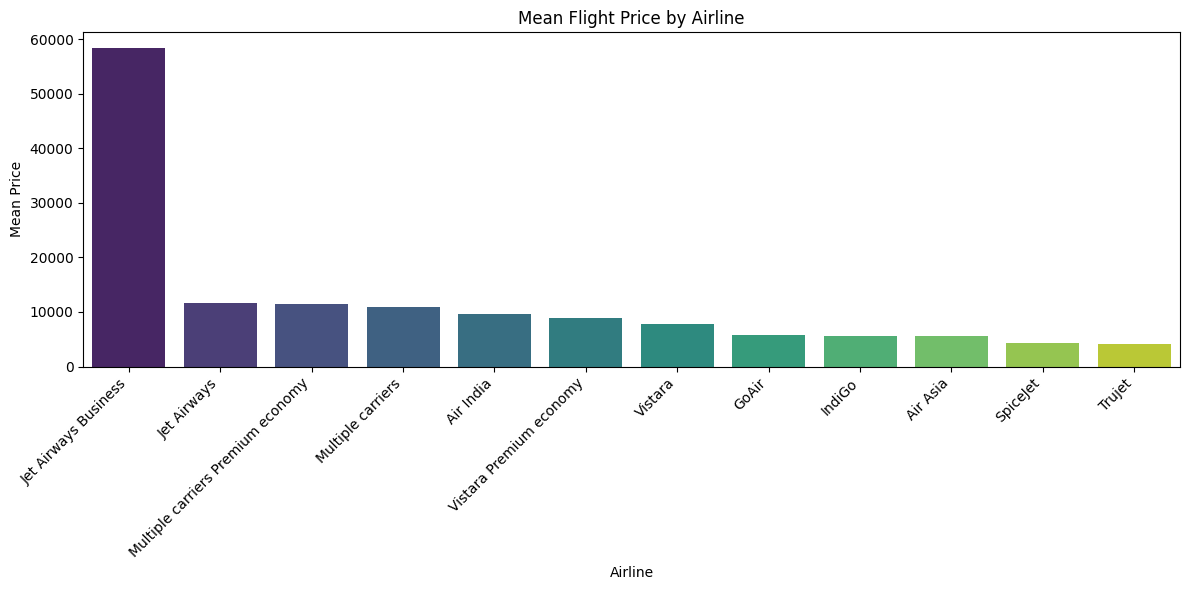

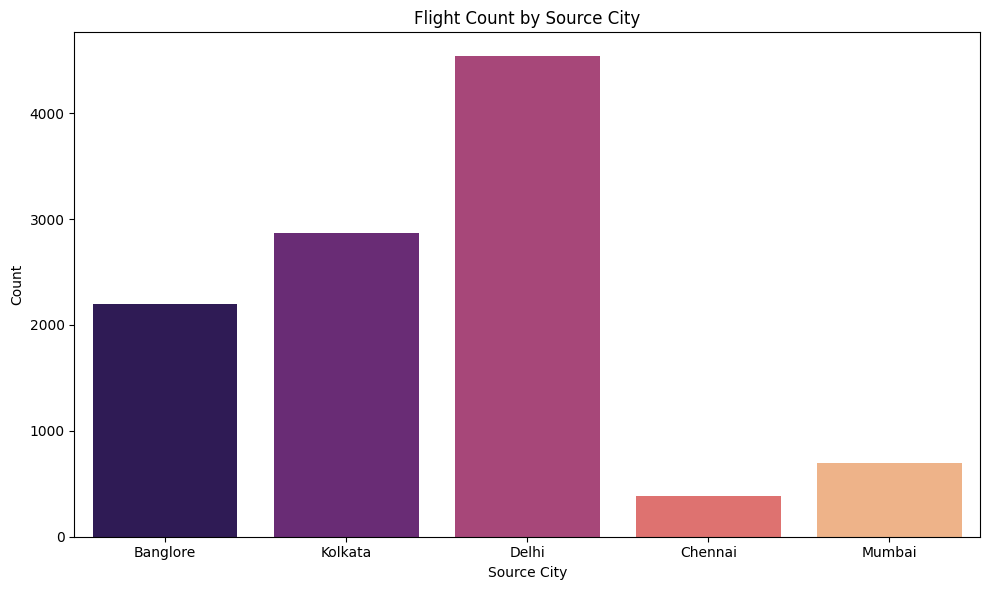

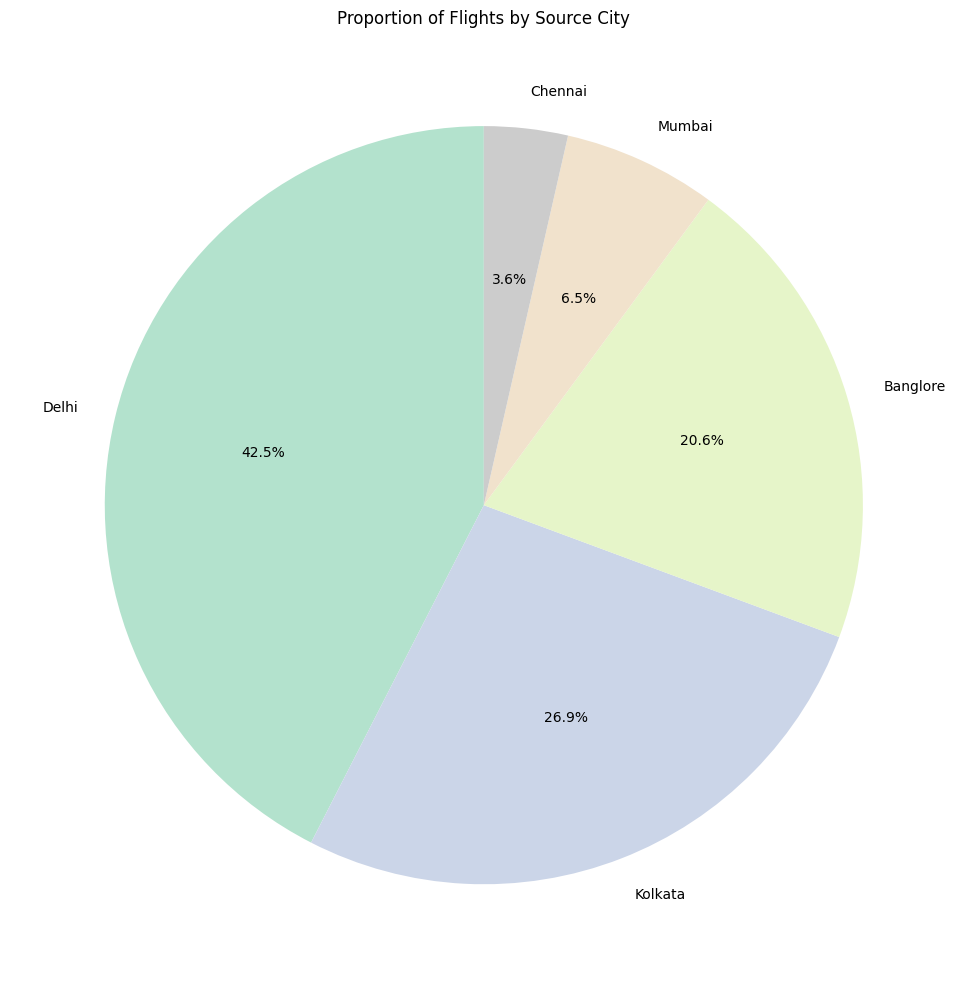

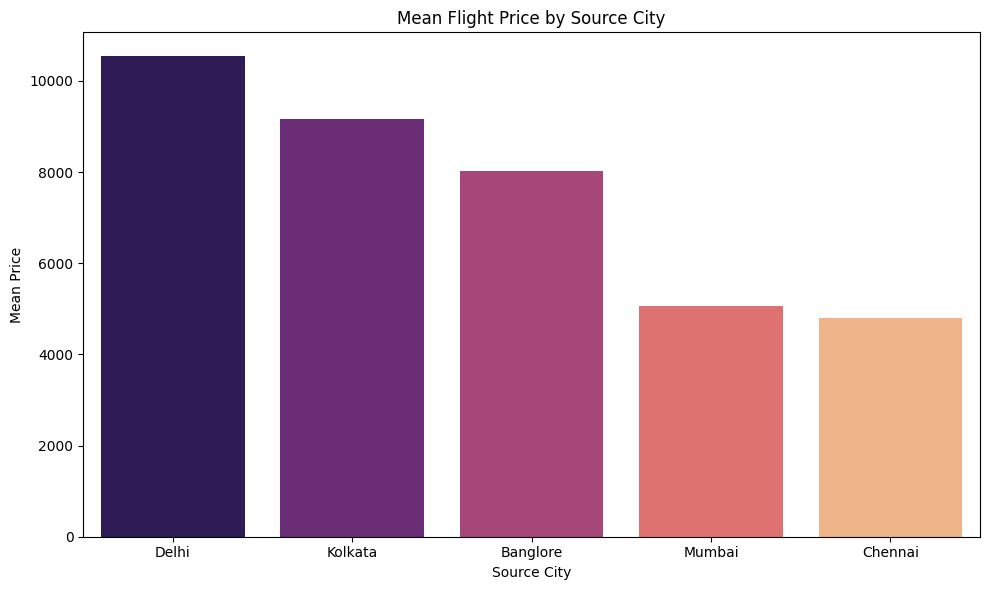

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Airline', data=original_df_for_chi2, palette='viridis', hue='Airline', legend=False)
plt.title('Flight Count by Airline')
plt.xlabel('Airline')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 1.b. Create a pie chart illustrating the proportion of flights for each airline.
plt.figure(figsize=(10, 10))
original_df_for_chi2['Airline'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='Pastel1')
plt.title('Proportion of Flights by Airline')
plt.ylabel('') # Hide the default 'Airline' label
plt.tight_layout()
plt.show()

# 1.c. Create a bar plot showing the mean 'Price' for each airline.
plt.figure(figsize=(12, 6))
mean_price_by_airline = original_df_for_chi2.groupby('Airline')['Price'].mean().sort_values(ascending=False)
sns.barplot(x=mean_price_by_airline.index, y=mean_price_by_airline.values, palette='viridis', hue=mean_price_by_airline.index, legend=False)
plt.title('Mean Flight Price by Airline')
plt.xlabel('Airline')
plt.ylabel('Mean Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2.a. Create a bar plot showing the count of flights for each source city.
plt.figure(figsize=(10, 6))
sns.countplot(x='Source', data=original_df_for_chi2, palette='magma', hue='Source', legend=False)
plt.title('Flight Count by Source City')
plt.xlabel('Source City')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 2.b. Create a pie chart illustrating the proportion of flights from each source city.
plt.figure(figsize=(10, 10))
original_df_for_chi2['Source'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='Pastel2')
plt.title('Proportion of Flights by Source City')
plt.ylabel('') # Hide the default 'Source' label
plt.tight_layout()
plt.show()

# 2.c. Create a bar plot showing the mean 'Price' for each source city.
plt.figure(figsize=(10, 6))
mean_price_by_source = original_df_for_chi2.groupby('Source')['Price'].mean().sort_values(ascending=False)
sns.barplot(x=mean_price_by_source.index, y=mean_price_by_source.values, palette='magma', hue=mean_price_by_source.index, legend=False)
plt.title('Mean Flight Price by Source City')
plt.xlabel('Source City')
plt.ylabel('Mean Price')
plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

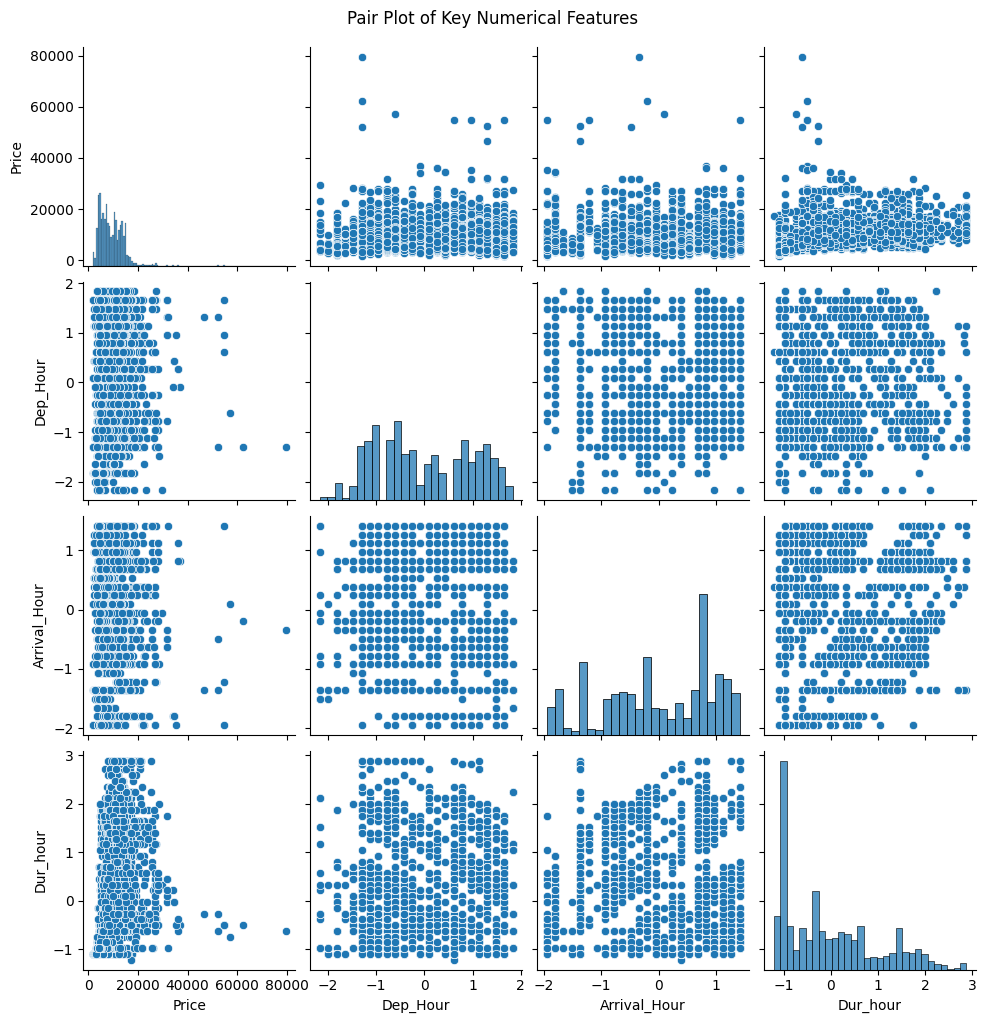

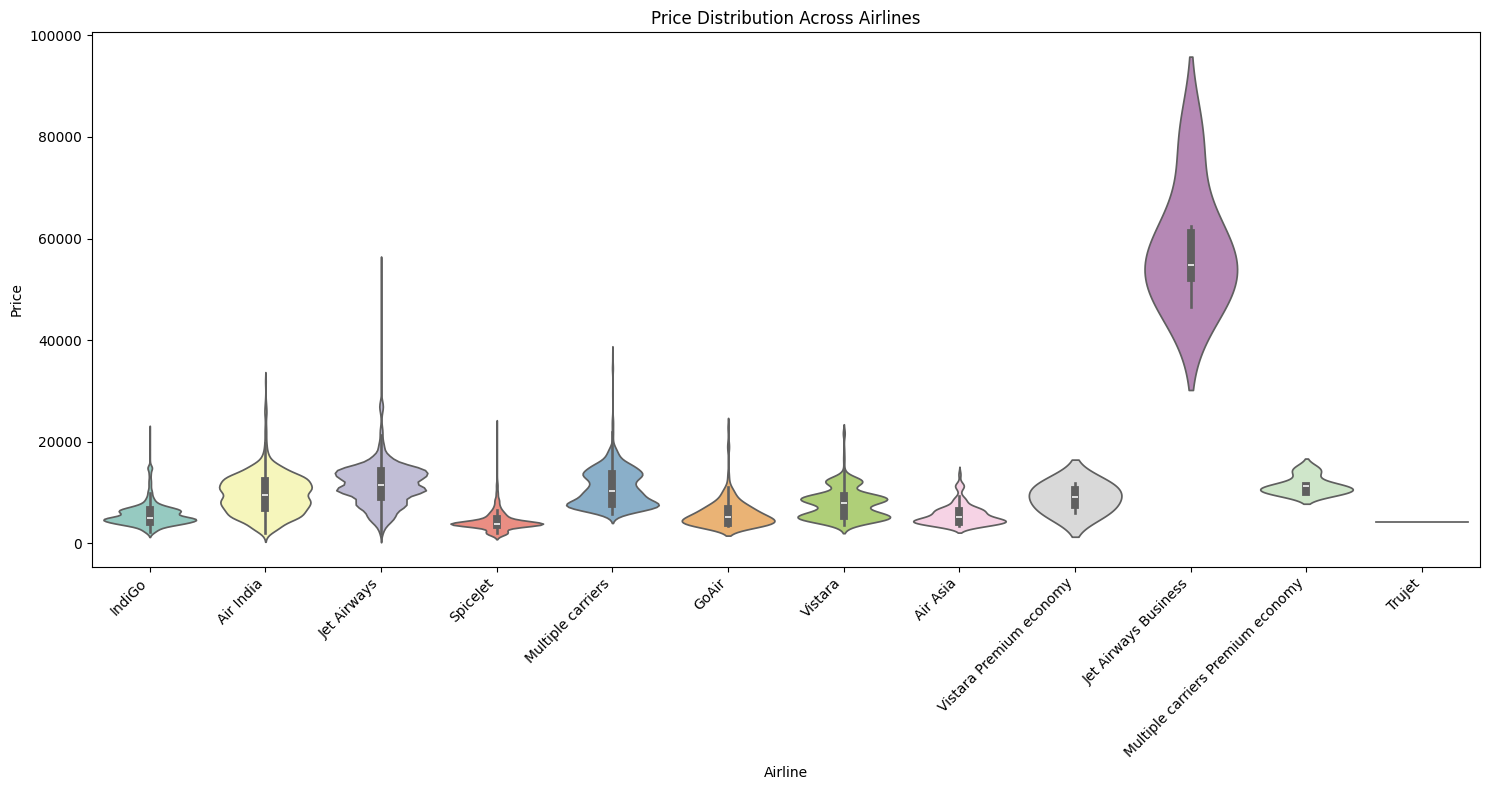

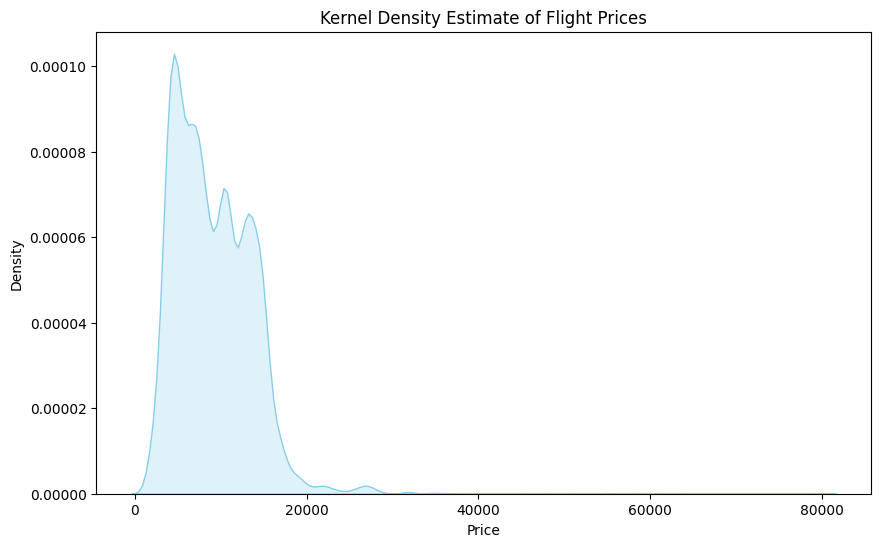

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a pair plot for selected numerical features
key_numerical_features = ['Price', 'Dep_Hour', 'Arrival_Hour', 'Dur_hour']
plt.figure(figsize=(12, 10)) # Adjust figure size for better readability of subplots within pairplot
sns.pairplot(df1[key_numerical_features])
plt.suptitle('Pair Plot of Key Numerical Features', y=1.02) # Add a title for the entire pair plot
plt.show()

# 2. Create a violin plot for 'Price' across different 'Airline' categories
plt.figure(figsize=(15, 8))
sns.violinplot(x='Airline', y='Price', data=original_df_for_chi2, palette='Set3', hue='Airline', legend=False)
plt.title('Price Distribution Across Airlines')
plt.xlabel('Airline')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3. Create a Kernel Density Estimate (KDE) plot for the 'Price' column
plt.figure(figsize=(10, 6))
sns.kdeplot(df1['Price'], fill=True, color='skyblue')
plt.title('Kernel Density Estimate of Flight Prices')
plt.xlabel('Price')
plt.ylabel('Density')
plt.show()

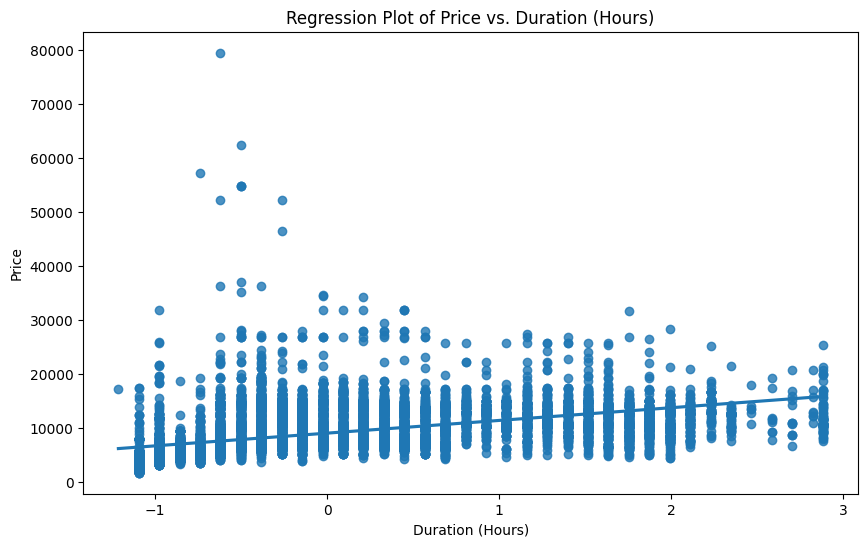

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Dur_hour', y='Price', data=df1)
plt.title('Regression Plot of Price vs. Duration (Hours)')
plt.xlabel('Duration (Hours)')
plt.ylabel('Price')
plt.show()

In [ ]:
original_df_for_chi2['Month'] = original_df_for_chi2['Date_of_Journey'].str.split('/').str[1].astype(int)

# Calculate the average price per month
avg_price_per_month = original_df_for_chi2.groupby('Month')['Price'].mean().reset_index()

# Create an interactive line chart
fig = px.line(avg_price_per_month, x='Month', y='Price', markers=True,
              title='Average Flight Price Trend by Month',
              labels={'Month': 'Month of Journey', 'Price': 'Average Flight Price'})

fig.show()

In [ ]:
import pandas as pd

# Aggregate data by Source city
source_data = original_df_for_chi2.groupby('Source').agg(
    flight_count=('Price', 'count'),
    average_price=('Price', 'mean')
).reset_index()

print(source_data.head())


     Source  flight_count  average_price
0  Banglore          2197    8017.464269
1   Chennai           381    4789.892388
2     Delhi          4537   10539.439057
3   Kolkata          2871    9158.389411
4    Mumbai           697    5059.708752


In [ ]:
city_coordinates = {
    'Banglore': {'lat': 12.9716, 'lon': 77.5946},
    'Chennai': {'lat': 13.0827, 'lon': 80.2707},
    'Delhi': {'lat': 28.7041, 'lon': 77.1025},
    'Kolkata': {'lat': 22.5726, 'lon': 88.3639},
    'Mumbai': {'lat': 19.0760, 'lon': 72.8777}
}

# Map coordinates to the source_data DataFrame
source_data['lat'] = source_data['Source'].map(lambda x: city_coordinates[x]['lat'])
source_data['lon'] = source_data['Source'].map(lambda x: city_coordinates[x]['lon'])

print(source_data.head())

     Source  flight_count  average_price      lat      lon
0  Banglore          2197    8017.464269  12.9716  77.5946
1   Chennai           381    4789.892388  13.0827  80.2707
2     Delhi          4537   10539.439057  28.7041  77.1025
3   Kolkata          2871    9158.389411  22.5726  88.3639
4    Mumbai           697    5059.708752  19.0760  72.8777


In [ ]:
import plotly.express as px

# Create an interactive choropleth map using scatter_mapbox
fig = px.scatter_mapbox(source_data,
                        lat="lat",
                        lon="lon",
                        size="flight_count", # Size of the bubble based on flight count
                        color="average_price", # Color of the bubble based on average price
                        hover_name="Source",
                        hover_data={'flight_count': True, 'average_price': ':.2f', 'lat': False, 'lon': False},
                        zoom=3,
                        height=600,
                        title='Flight Data by Source City (Bubble Map)',
                        color_continuous_scale=px.colors.sequential.Plasma,
                        mapbox_style="open-street-map")

fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

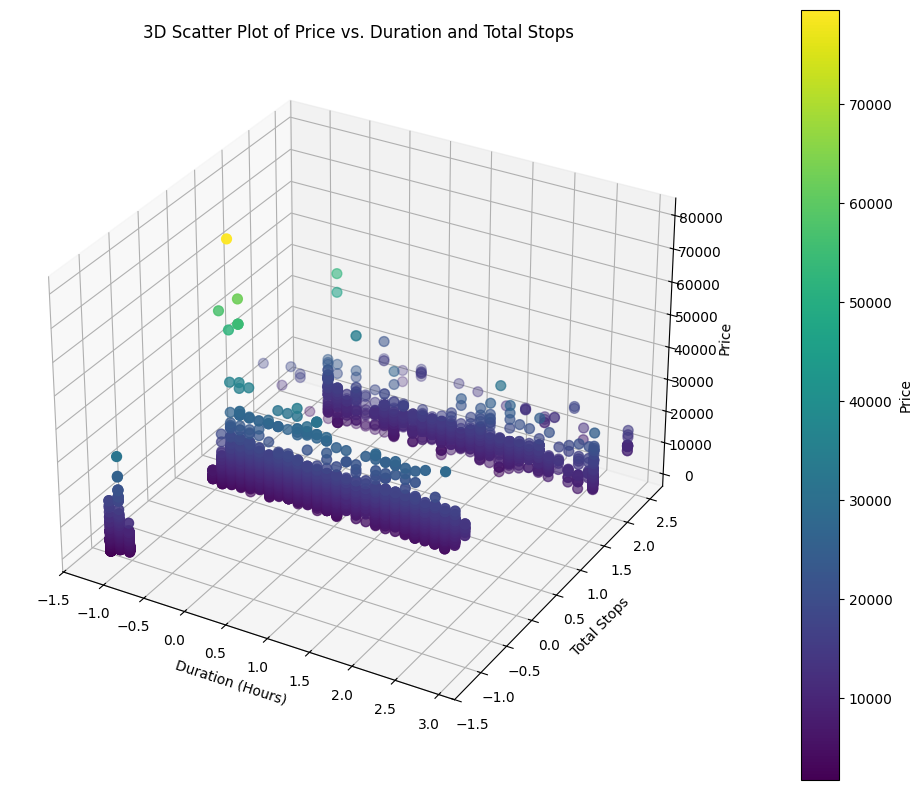

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D scatter plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Ensure 'Total_Stops' column does not have NaN values for plotting
df1_plot = df1.dropna(subset=['Total_Stops'])

# Plotting the scatter plot
scatter = ax.scatter(df1_plot['Dur_hour'], df1_plot['Total_Stops'], df1_plot['Price'],
                     c=df1_plot['Price'], cmap='viridis', s=50)

ax.set_xlabel('Duration (Hours)')
ax.set_ylabel('Total Stops')
ax.set_zlabel('Price')
ax.set_title('3D Scatter Plot of Price vs. Duration and Total Stops')

# Add a color bar
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Price')

plt.show()

In [ ]:
aggregated_prices = original_df_for_chi2.groupby(['Airline', 'Source'])['Price'].agg(['mean', 'min', 'max']).reset_index()

print("Aggregated Flight Prices by Airline and Source:")
print(aggregated_prices.head())


Aggregated Flight Prices by Airline and Source:
     Airline    Source         mean   min    max
0   Air Asia  Banglore  4574.280899  3383  10873
1   Air Asia     Delhi  7804.175000  6151  13774
2   Air Asia   Kolkata  5012.320000  3782  11323
3  Air India  Banglore  9238.198795  3758  31783
4  Air India   Chennai  5895.640000  3145  19630


In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

# Fill NaN values in 'Total_Stops' with its mode before feature selection
# The mode is calculated from the numerical_features_to_analyze in cell 3887c8ec where it was clear that Total_Stops is a float64 after scaling.
# The mode of the scaled 'Total_Stops' is likely its most frequent scaled value.
# Let's re-calculate the mode of the 'Total_Stops' column from df1 as it is currently in its scaled form.
mode_total_stops_scaled = df1['Total_Stops'].mode()[0]
df1['Total_Stops'] = df1['Total_Stops'].fillna(mode_total_stops_scaled)

# Identify numerical columns for features, excluding 'Price'
numerical_cols = df1.select_dtypes(include=['int64', 'float64']).columns.drop('Price')

# Separate features (X) and target (y)
X = df1[numerical_cols]
y = df1['Price']

# Instantiate SelectKBest with f_regression and k=10
k = 10
selector = SelectKBest(score_func=f_regression, k=k)

# Fit the selector to the data
selector.fit(X, y)

# Get the indices of the selected features
selected_feature_indices = selector.get_support(indices=True)

# Get the names of the selected features
selected_features = X.columns[selected_feature_indices]

print(f"Top {k} selected numerical features:\n{selected_features.tolist()}")

Top 10 selected numerical features:
['Total_Stops', 'Dur_hour', 'Airline_IndiGo', 'Airline_Jet Airways', 'Airline_Jet Airways Business', 'Airline_SpiceJet', 'Source_Delhi', 'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad']


In [ ]:
import numpy as np

# Extract Dur_hour and Dur_min from the 'Duration' column
original_df_for_chi2['Dur_hour'] = original_df_for_chi2['Duration'].str.split(' ').str[0].str.replace('h', '')
# Handle cases where only hours are present (e.g., '19h'), set minutes to NaN for later imputation
original_df_for_chi2['Dur_min'] = original_df_for_chi2['Duration'].str.split(' ').str[1].str.replace('m', '')

# Convert to numeric, coercing errors to NaN
original_df_for_chi2['Dur_hour'] = pd.to_numeric(original_df_for_chi2['Dur_hour'], errors='coerce')
original_df_for_chi2['Dur_min'] = pd.to_numeric(original_df_for_chi2['Dur_min'], errors='coerce')

# Fill any NaN values in Dur_hour with 0 (for cases like '5m' duration, or malformed data)
original_df_for_chi2['Dur_hour'] = original_df_for_chi2['Dur_hour'].fillna(0).astype(int)
# Fill any NaN values in Dur_min with 0 (for cases like '19h' duration)
original_df_for_chi2['Dur_min'] = original_df_for_chi2['Dur_min'].fillna(0).astype(int)

# Calculate 'Total_Duration_minutes'
original_df_for_chi2['Total_Duration_minutes'] = original_df_for_chi2['Dur_hour'] * 60 + original_df_for_chi2['Dur_min']

# Extract 'Dep_Hour' from 'Dep_Time'
original_df_for_chi2['Dep_Hour'] = pd.to_numeric(original_df_for_chi2['Dep_Time'].str.split(':').str[0], errors='coerce').fillna(0).astype(int)

# Define a function to categorize departure time
def categorize_dep_time(hour):
    if 6 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 17:
        return 'Afternoon'
    elif 18 <= hour <= 23:
        return 'Evening'
    else:
        return 'Night'

# Create 'Departure_Time_Category' column
original_df_for_chi2['Departure_Time_Category'] = original_df_for_chi2['Dep_Hour'].apply(categorize_dep_time)

# Display the head of the DataFrame with new columns
display(original_df_for_chi2.head())

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Dur_hour,Month,Dur_min,Total_Duration_minutes,Dep_Hour,Departure_Time_Category
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,2,3,50,170,22,Evening
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,7,5,25,445,5,Night
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,19,6,0,1140,9,Morning
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,5,5,25,325,18,Evening
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,4,3,45,285,16,Afternoon


In [ ]:
from sklearn.decomposition import PCA

# Select the numerical features from df1 that were previously scaled, excluding the 'Price' column
numerical_cols_for_pca = df1.select_dtypes(include=['int64', 'float64']).columns.drop('Price')
X_scaled = df1[numerical_cols_for_pca]

print("Selected numerical features for PCA:")
print(X_scaled.head())

Selected numerical features for PCA:
   Total_Stops       Day     Month  Year  Arrival_Hour  Arrival_Minute  \
0    -1.229259  1.237383 -1.467490   0.0     -1.800427       -0.890057   
1     1.761845 -1.475239  0.250276   0.0     -0.050851       -0.587124   
2     1.761845 -0.531719  1.109160   0.0     -1.363033        0.018744   
3     0.266293 -0.177898  0.250276   0.0      1.407129        0.321677   
4     0.266293 -1.475239 -1.467490   0.0      1.115533        0.624611   

   Dep_Hour  Dep_Minute  Dur_hour   Dur_min  ...  Destination_New Delhi  \
0  1.654259   -0.235050 -0.976072  1.322625  ...                      1   
1 -1.303095    1.363492 -0.382640 -0.438556  ...                      0   
2 -0.607247    0.031373  1.041598 -0.086320  ...                      0   
3  0.958411   -1.034321 -0.620013 -0.438556  ...                      0   
4  0.610487    1.363492 -0.738699  0.970389  ...                      1   

   Additional_Info_1 Short layover  Additional_Info_2 Long layover 

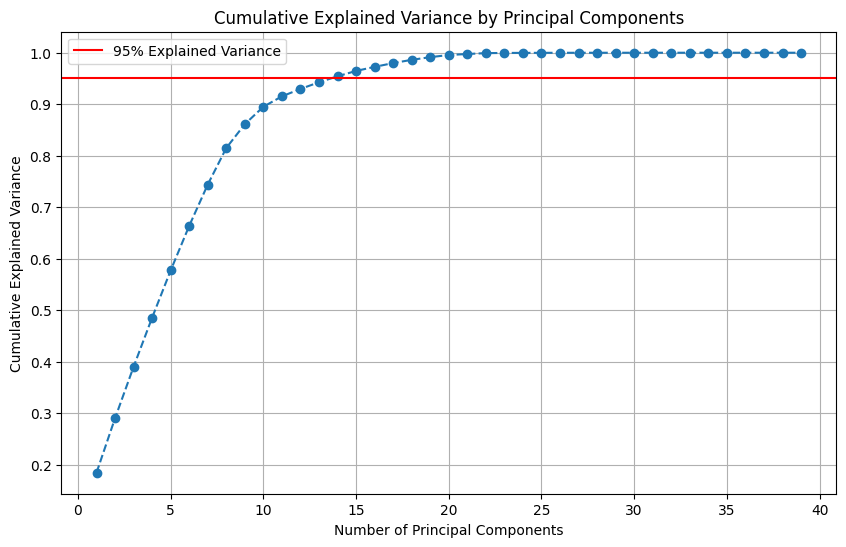

Explained variance ratio of first 5 components: [0.18432959 0.10587774 0.09987514 0.09539594 0.09168336]
Cumulative explained variance of first 5 components: [0.18432959 0.29020733 0.39008247 0.48547841 0.57716177]


In [ ]:
pca = PCA(n_components=None)
pca.fit(X_scaled)


explained_variance_ratio = pca.explained_variance_ratio_


cumulative_explained_variance = np.cumsum(explained_variance_ratio)


plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance')
plt.legend(loc='best')
plt.show()

print(f"Explained variance ratio of first 5 components: {explained_variance_ratio[:5]}")
print(f"Cumulative explained variance of first 5 components: {cumulative_explained_variance[:5]}")